<a href="https://colab.research.google.com/github/tlerksuthirat/CCA_parp_atr/blob/main/motorized_upright_microscope_usage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import auth
auth.authenticate_user()
import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Replace with sheet ID
instrument_url = 'https://docs.google.com/spreadsheets/d/1WBZS1PXpkSTeA4xpV0PVBvmPP5-ZYCelRcl3WKvS_TM/edit?gid=1451272003#gid=1451272003'

sheet_id = instrument_url .split('/')[-2]  # Extract sheet ID from URL
sheet = gc.open_by_key(sheet_id)

In [ ]:
#Get a list of all worksheets
worksheet_list = sheet.worksheets()

#Print the titles of all worksheets
for worksheet in worksheet_list:
    print(worksheet.title)

2026
2025
2024
Latest use
Productivity
2023
2022
2021
User list
Status


In [ ]:
#Choose a specific worksheet (e.g., '2026')
worksheet = sheet.worksheet('2026')

# Task
Analyze and visualize the monthly usage of the instrument from the '2025' worksheet of the Google Sheet located at "https://docs.google.com/spreadsheets/d/1WBZS1PXpkSTeA4xpV0PVBvmPP5-ZYCelRcl3WKvS_TM/edit?gid=1451272003#gid=1451272003", including data cleaning, calculation of total usage hours, and generation of a monthly usage table and graph.

## Run data loading cell

### Subtask:
Load data from the '2025' worksheet into a DataFrame.


**Reasoning**:
The subtask requires loading data from the `worksheet` into a Pandas DataFrame. Since the `data` variable from the kernel state appears to already contain the records from the worksheet, I will use it to create the DataFrame. The first row of `data` will be used as column headers.



In [ ]:
# Fetch data from the worksheet
data = worksheet.get_all_values()

headers = data[0]
df = pd.DataFrame(data[1:], columns=headers)
print(df.head())

  Date of use (MM/DD/YY) Start (00:00-24:00) End (00:00-24:00) Duration (hr)  \
0             1-Jan-2026                0:00              0:00          0:00   
1             7-Jan-2026               15:30             17:00          1:30   
2             9-Jan-2026               10:30             12:30          2:00   
3            14-Jan-2026                9:00             10:00          1:00   
4            15-Jan-2026               14:00             16:00          2:00   

  Technique Condition              User name  \
0  IF or BF      Okay  Tassanee Lerksuthirat   
1        IF      Okay       Pawarit Innachai   
2        IF      Okay       Pawarit Innachai   
3        IF      Okay       Pawarit Innachai   
4        IF      Okay       Pawarit Innachai   

                                                Note  
0                   Demo how to fill in the log book  
1  The Locate mode configuration is not respondin...  
2  The configuration has been corrected by the pr...  
3         

In [ ]:
# Remove the first row (index 0) which often contains metadata or repeated headers after loading.
df_cleaned = df.iloc[1:].copy()

# Replace empty strings with NaN for proper dropping
df_cleaned.replace('', pd.NA, inplace=True)

# Drop rows where 'Date of use (MM/DD/YY)' is missing, as these are critical for time-based analysis.
column_to_check = 'Date of use (MM/DD/YY)'
df_cleaned.dropna(subset=[column_to_check], inplace=True)

# Display the head of the cleaned DataFrame
print("Cleaned DataFrame head:")
display(df_cleaned.head())

Cleaned DataFrame head:


,Date of use (MM/DD/YY),Start (00:00-24:00),End (00:00-24:00),Duration (hr),Technique,Condition,User name,Note
1,7-Jan-2026,15:30,17:00,1:30,IF,Okay,Pawarit Innachai,The Locate mode configuration is not respondin...
2,9-Jan-2026,10:30,12:30,2:00,IF,Okay,Pawarit Innachai,The configuration has been corrected by the pr...
3,14-Jan-2026,9:00,10:00,1:00,IF,Okay,Pawarit Innachai,<NA>
4,15-Jan-2026,14:00,16:00,2:00,IF,Okay,Pawarit Innachai,<NA>
5,19-Jan-2026,13:00,16:00,3:00,IF,Okay,Pawarit Innachai,<NA>


In [ ]:
def time_string_to_seconds_flexible(row):
    time_str = row['Duration (hr)']

    if pd.isna(time_str) or time_str == '':
        return 0  # Handle missing or empty values

    # Ensure time_str is a string before splitting
    time_str = str(time_str).strip()

    try:
        parts = list(map(int, time_str.split(':')))

        if len(parts) == 2:
            # Assuming H:M format
            h, m = parts
            s = 0 # Seconds are 0 if only H:M is provided
        elif len(parts) == 3:
            # Assuming H:M:S format
            h, m, s = parts
        else:
            # Handle cases with unexpected number of parts, or just a single number (hours)
            if len(parts) == 1:
                h = parts[0]
                m = 0
                s = 0
            else:
                print(f"Warning: Unexpected time format '{time_str}' at index {row.name}. Returning 0.")
                return 0

        total_seconds = h * 3600 + m * 60 + s
        return total_seconds

    except ValueError:
        print(f"Warning: Could not convert time parts to integers for '{time_str}' at index {row.name}. Returning 0.")
        return 0
    except Exception as e:
        print(f"An unexpected error occurred processing '{time_str}' at index {row.name}: {e}. Returning 0.")
        return 0

# Apply the function to create 'Total Seconds' column
df_cleaned['Total Seconds'] = df_cleaned.apply(time_string_to_seconds_flexible, axis=1)

# Calculate 'Total Hours'
df_cleaned['Total Hours'] = df_cleaned['Total Seconds'] / 3600

print("DataFrame with Total Seconds and Total Hours:")
display(df_cleaned[['Date of use (MM/DD/YY)', 'Duration (hr)', 'Total Seconds', 'Total Hours']].head())

DataFrame with Total Seconds and Total Hours:


,Date of use (MM/DD/YY),Duration (hr),Total Seconds,Total Hours
1,7-Jan-2026,1:30,5400,1.5
2,9-Jan-2026,2:00,7200,2.0
3,14-Jan-2026,1:00,3600,1.0
4,15-Jan-2026,2:00,7200,2.0
5,19-Jan-2026,3:00,10800,3.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy to avoid SettingWithCopyWarning
df_monthly_usage = df_cleaned.copy()

# Convert 'Date of use (MM/DD/YY)' to datetime objects
df_monthly_usage.loc[:, 'Date'] = pd.to_datetime(df_monthly_usage['Date of use (MM/DD/YY)'], errors='coerce')

# Drop rows where 'Date' could not be parsed (if any)
df_monthly_usage.dropna(subset=['Date'], inplace=True)

# Extract month name and numeric month for proper sorting
df_monthly_usage.loc[:, 'Month_Name'] = df_monthly_usage['Date'].dt.strftime('%B') # Full month name
df_monthly_usage.loc[:, 'Month_Num'] = df_monthly_usage['Date'].dt.month

# Group by 'User name' and 'Month' and sum 'Total Hours'
monthly_usage_summary = df_monthly_usage.groupby(['User name', 'Month_Num', 'Month_Name'])['Total Hours'].sum().reset_index()

# Sort by Month_Num to ensure chronological order
monthly_usage_summary = monthly_usage_summary.sort_values(by=['Month_Num', 'User name'])

# Display the table, pivoting to show months as columns
monthly_usage_pivot = monthly_usage_summary.pivot_table(index='User name', columns='Month_Name', values='Total Hours', fill_value=0)

# Reorder columns chronologically if needed (based on Month_Num from original data)
month_order_chronological = df_monthly_usage.sort_values('Date')['Month_Name'].unique()
monthly_usage_pivot = monthly_usage_pivot[month_order_chronological]

print("\n--- Monthly Usage Hours per User Table ---")
display(monthly_usage_pivot.round(1))


--- Monthly Usage Hours per User Table ---


Month_Name,January,February,March,April
User name,,,,
Chalisa Jaturapaktrarak,0.0,0.0,1.0,0.0
Gunn Pornratananont,0.0,0.0,4.0,0.0
Pawarit Innachai,28.5,17.5,28.5,5.0
Rakkreat Wikiniyadhanee,0.0,1.0,0.0,0.0
Sathida Liekwannacharoen,0.0,9.0,13.5,8.2
Tassanee Lerksuthirat,0.0,0.0,11.2,2.0
Wilasinee Konsue,0.0,0.0,15.8,17.1



--- Total Usage Hours Per Month Year 2026---


,Month_Name,Total Hours
2,January,28.5
1,February,27.5
3,March,74.0
0,April,32.3


/tmp/ipykernel_4728/2923708662.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_total_usage, x='Month_Name', y='Total Hours', palette='Paired')


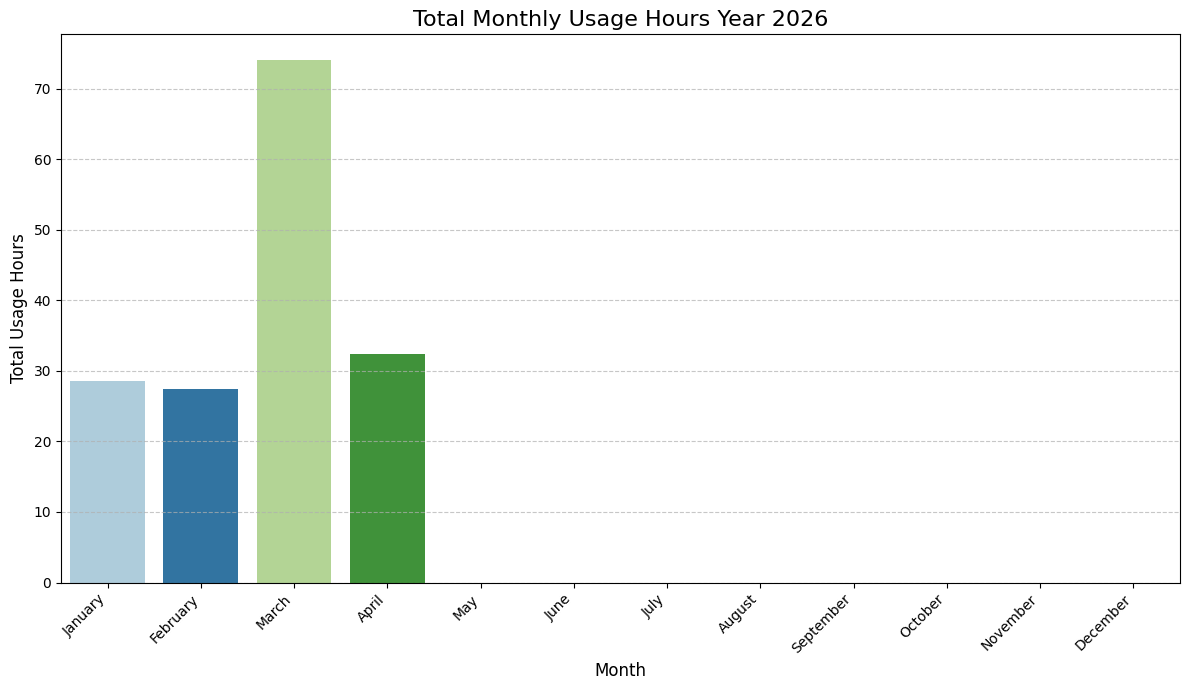

In [ ]:
# Calculate the total usage hours per month
monthly_total_usage = df_monthly_usage.groupby('Month_Name')['Total Hours'].sum().reset_index()

# Reorder months chronologically for display
month_order_chronological = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_total_usage['Month_Name'] = pd.Categorical(monthly_total_usage['Month_Name'], categories=month_order_chronological, ordered=True)
monthly_total_usage = monthly_total_usage.sort_values('Month_Name')

print("\n--- Total Usage Hours Per Month Year 2026---")
display(monthly_total_usage.round(1))

# Create the bar plot for total monthly usage
plt.figure(figsize=(12, 7))
sns.barplot(data=monthly_total_usage, x='Month_Name', y='Total Hours', palette='Paired')
plt.title('Total Monthly Usage Hours Year 2026', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Usage Hours', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

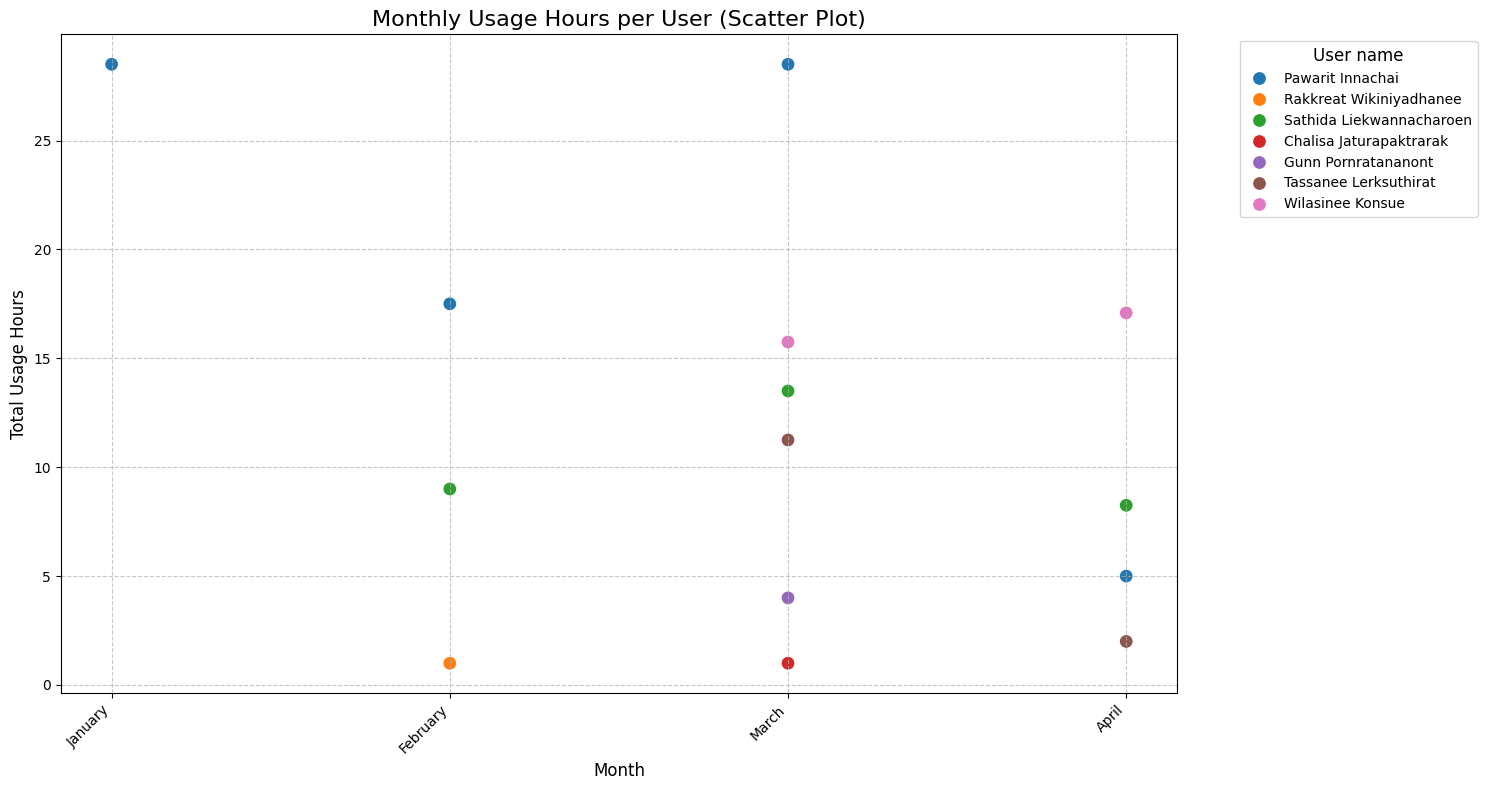

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure Month_Name is a categorical type with chronological order for plotting
month_order_chronological = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_usage_summary['Month_Name'] = pd.Categorical(monthly_usage_summary['Month_Name'], categories=month_order_chronological, ordered=True)

# Sort the DataFrame by Month_Name to ensure correct order on plot
monthly_usage_summary_sorted = monthly_usage_summary.sort_values(by='Month_Name')

plt.figure(figsize=(15, 8))
sns.scatterplot(data=monthly_usage_summary_sorted, x='Month_Name', y='Total Hours', hue='User name', s=100, palette='tab10')
plt.title('Monthly Usage Hours per User (Scatter Plot)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Usage Hours', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='User name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This scatter plot visualizes the monthly usage hours for each user. The x-axis represents the months, and the y-axis shows the total usage hours. Each point on the plot corresponds to a specific user's total hours for a given month, with different colors distinguishing between users. This allows you to observe individual user trends and identify any outliers or consistent usage patterns across the months.

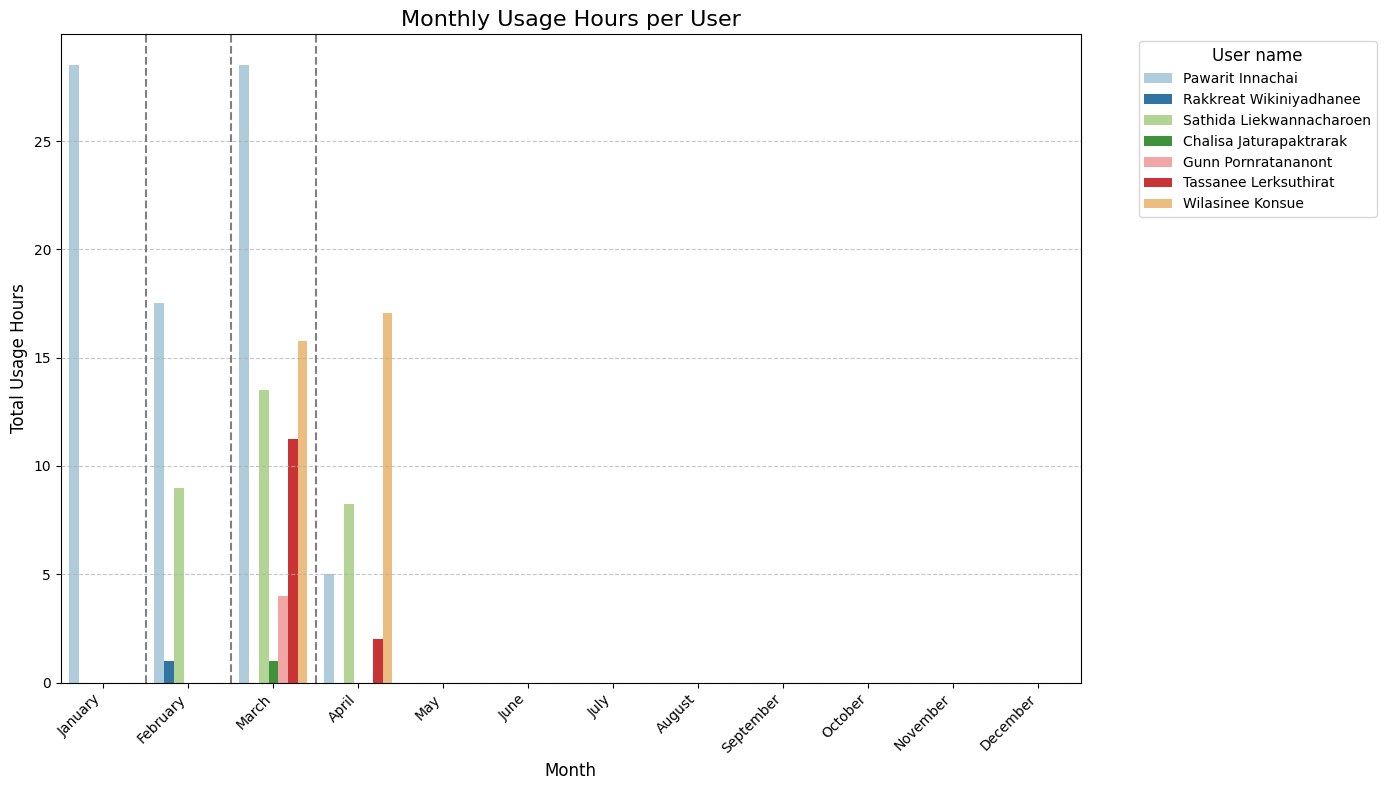

In [ ]:
# Create the bar plot for monthly usage per user
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=monthly_usage_summary, x='Month_Name', y='Total Hours', hue='User name', palette='Paired')
plt.title('Monthly Usage Hours per User', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Usage Hours', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='User name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add dashed lines to separate months
# The number of unique months determines where to place the lines
num_months = len(monthly_usage_summary['Month_Name'].unique())
for i in range(num_months - 1):
    ax.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()